Notebook for generating plots after benching french STT models

In [9]:
import os
import json
import pandas as pd
import numpy as np

from asr_benchmark.visualization.plots import prepare_data, plot_violin_df, plot_wer_df, plot_bar_df
from asr_benchmark.utils.visualize import load_data

pd.set_option("future.no_silent_downcasting", True)

In [10]:
INPUT_FOLDER = "local_bench_fr"
OUTPUT_FOLDER = "local_plots"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
df = pd.DataFrame(load_data(INPUT_FOLDER))

100%|██████████| 9/9 [00:00<00:00, 26.36it/s]


In [11]:
print(df["dataset"].unique())
df["dataset"] = df["dataset"].replace({
    "YouTubeFr_split6": "YouTube",
    "TEDX_fr": "TEDx",
    "MLS_Facebook_french": "MLS",
    "Voxpopuli": "VoxPopuli"
})
print(df["dataset"].unique())
datasets = ['CommonVoice', 'MLS', 'SUMM-RE', 'VoxPopuli', 'TEDx', 'YouTube']
all_models = df["model"].unique()
print(all_models)
models = all_models

['CommonVoice' 'MLS_Facebook_french' 'SUMM-RE' 'TEDX_fr' 'Voxpopuli'
 'YouTubeFr_split6']
['CommonVoice' 'MLS' 'SUMM-RE' 'TEDx' 'VoxPopuli' 'YouTube']
['bofenghuang/whisper-large-v3-french-distil-dec8'
 'bofenghuang/whisper-large-v3-french' 'whisper-large-v3-turbo'
 'whisper-large-v3' 'bofenghuang/stt-fr-fastconformer-hybrid-large'
 'nvidia/canary-1b' 'nvidia/stt-fr-fastconformer-hybrid-large-pc'
 'stt-fr-fastconformer-hybrid-large-finetuned-v2'
 'stt-fr-fastconformer-hybrid-large-finetuned']


In [12]:
for x in datasets:
    selected_rows = df[
        ((df["device"] == "cuda"))
        & (df['dataset'] == x)
        # & (~df['process_duration'].isnull())
        & (df['model'].isin(models))
        & ((df["decoder"] == "rnnt") | (df["decoder"].isnull()))
    ]
    selected_rows = prepare_data(selected_rows, return_format="df")
    local_output_folder = os.path.join(OUTPUT_FOLDER, "model")
    os.makedirs(local_output_folder, exist_ok=True)
    selected_rows.sort_values(by="model", inplace=True, ascending=True)
    rows_dict = prepare_data(selected_rows, return_format="dict")
    plot_wer_df(rows_dict, local_output_folder, x_column="model", title=f"WER on {x}", save_fig=f"model_wer_{x}")

In [13]:
from asr_benchmark.visualization.table import df_to_wer_table_format, plot_wer_table, generate_markdown_table_with_std, prepare_model_name, reorder_wer_pivot

wer_pivot, wer_std_pivot, wer_conf_pivot = df_to_wer_table_format(df)

/mnt/c/Users/berta/Documents/Linagora/asr_benchmark/asr_benchmark/visualization/table.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['wer_mean'] = df_filtered['wer'].apply(lambda x: np.mean(x) if isinstance(x, list) and x else None)
/mnt/c/Users/berta/Documents/Linagora/asr_benchmark/asr_benchmark/visualization/table.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['wer_std'] = df_filtered['wer'].apply(lambda x: np.std(x) if isinstance(x, list) and x else None)
/mnt/c/Users/

In [14]:
# Assuming wer_pivot is your pivoted DataFrame (models as rows, datasets as columns)
markdown_table = generate_markdown_table_with_std(wer_pivot, wer_conf_pivot)
with open(os.path.join(OUTPUT_FOLDER, "wer_table.md"), "w") as f:
    f.write(markdown_table)
print(markdown_table)

| Model | CommonVoice | MLS | SUMM-RE | TEDx | VoxPopuli | YouTube |
|:--|:--:|:--:|:--:|:--:|:--:|:--:|
| bofenghuang/stt-fr-fastconformer-hybrid-large   | 9.07 ± 1.08  | 4.99 ± 0.96  | 32.24 ± 1.35 | 11.98 ± 1.33 | 11.51 ± 1.40 | 30.22 ± 1.27 |
| bofenghuang/whisper-large-v3-french             | **8.37 ± 1.03** | 4.63 ± 0.82  | 23.12 ± 1.18 | 9.95 ± 1.23  | 11.28 ± 1.61 | 23.48 ± 1.27 |
| bofenghuang/whisper-large-v3-french-distil-dec8 | 8.75 ± 1.01  | **4.43 ± 0.72** | 21.72 ± 1.17 | 9.88 ± 1.23  | 11.50 ± 1.75 | 22.93 ± 1.27 |
| nvidia/canary-1b                                | 11.03 ± 1.25 | 7.61 ± 2.72  | **19.41 ± 3.79** | 36.94 ± 24.99 | 12.14 ± 2.11 | 31.02 ± 2.35 |
| nvidia/stt-fr-fastconformer-hybrid-large-pc     | 11.34 ± 1.19 | 6.71 ± 1.10  | 33.34 ± 1.40 | 18.82 ± 1.52 | **11.03 ± 1.33** | 29.15 ± 1.28 |
| stt-fr-fastconformer-hybrid-large-finetuned     | 11.35 ± 1.23 | 5.42 ± 1.01  | 23.13 ± 1.30 | 14.00 ± 1.42 | 12.74 ± 1.36 | 20.32 ± 1.24 |
| stt-fr-fastconformer-hybri

/mnt/c/Users/berta/Documents/Linagora/asr_benchmark/asr_benchmark/visualization/table.py:76: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fontweight = 'bold' if wer_means.index[i] == min_indices[j] else 'normal'


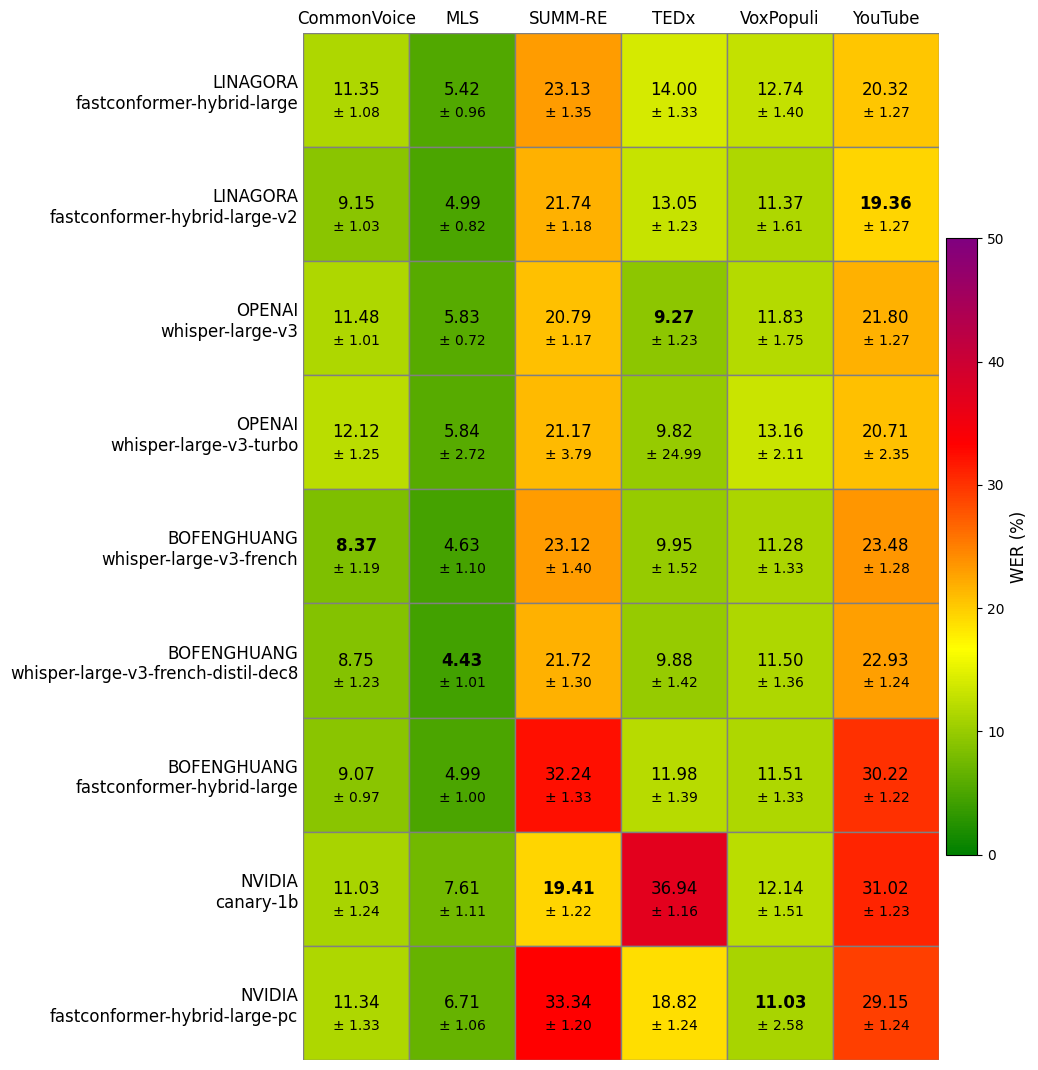

In [15]:
wer_pivot.index = [prepare_model_name(name) for name in wer_pivot.index]
wer_pivot = reorder_wer_pivot(wer_pivot)
plot_wer_table(wer_pivot, wer_conf_pivot, os.path.join(OUTPUT_FOLDER, "wer_table.png"))